# 01 — INbreast Dataset Exploration
**Goal:** Understand the raw data before any processing

Steps covered:
1. Raw DICOM inspection
2. Raw XML annotation inspection  
3. Interim PNG + Masks inspection
4. Processed images (after preprocessing)
5. Segmentation patches

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
import plistlib
from pathlib import Path

RAW_DIR    = Path('../data/raw/inbreast/INbreast Release 1.0')
INT_PNG    = Path('../data/interim/inbreast/AllPng')
INT_MASK   = Path('../data/interim/inbreast/Masks')
PROC_PNG   = Path('../data/processed/inbreast/AllPng')
PROC_MASK  = Path('../data/processed/inbreast/Masks')
PATCH_ALL  = Path('../data/patches/segmentation/all')
PATCH_TEST = Path('../data/patches/segmentation/test')
CSV_PATH   = Path('../data/interim/inbreast/inbreast_mc.csv')

print('Setup complete')

Setup complete


## 1. Raw DICOM Files

Total DICOM files: 410


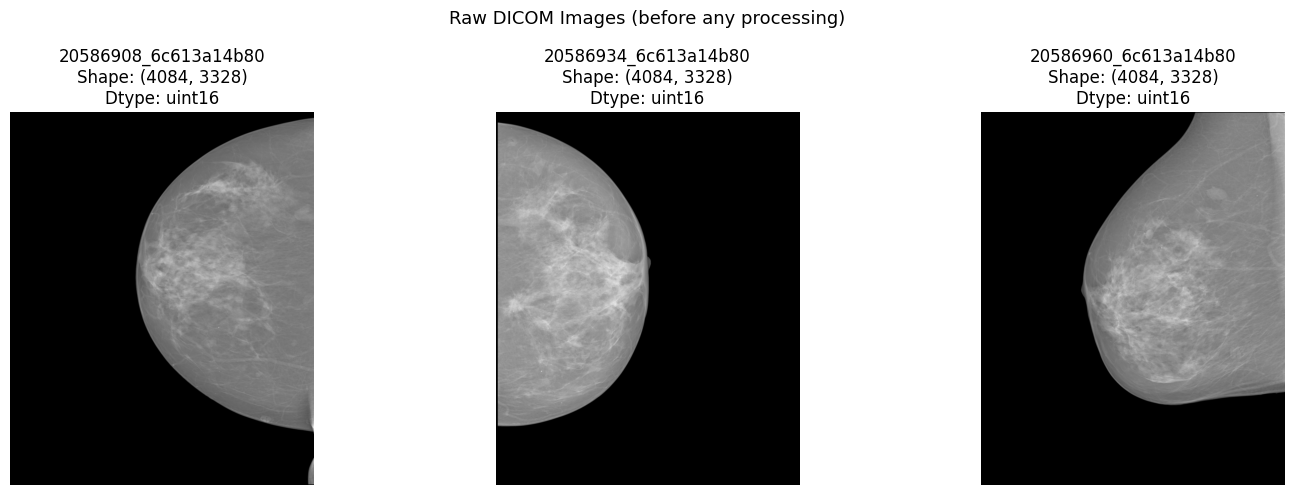


Sample DICOM metadata:
  Pixel array shape : (4084, 3328)
  Pixel dtype       : uint16
  Pixel min/max     : 0 / 2970


In [2]:
dcm_files = sorted((RAW_DIR / 'AllDICOMs').glob('*.dcm'))
print(f'Total DICOM files: {len(dcm_files)}')

# Read and show 3 DICOMs
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Raw DICOM Images (before any processing)', fontsize=13)
for i, dcm_path in enumerate(dcm_files[:3]):
    ds  = pydicom.dcmread(str(dcm_path))
    img = ds.pixel_array
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'{dcm_path.name[:20]}\nShape: {img.shape}\nDtype: {img.dtype}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Stats
ds = pydicom.dcmread(str(dcm_files[0]))
print(f'\nSample DICOM metadata:')
print(f'  Pixel array shape : {ds.pixel_array.shape}')
print(f'  Pixel dtype       : {ds.pixel_array.dtype}')
print(f'  Pixel min/max     : {ds.pixel_array.min()} / {ds.pixel_array.max()}')

## 2. Raw XML Annotations

In [3]:
xml_files = sorted((RAW_DIR / 'AllXML').glob('*.xml'))
print(f'Total XML files: {len(xml_files)}')

# Analyze annotation types
type_counts = {}
name_counts = {}
n_mc_files  = 0

for xml_path in xml_files:
    with open(str(xml_path), 'rb') as f:
        plist = plistlib.load(f)
    rois = plist.get('Images', [{}])[0].get('ROIs', [])
    has_mc = False
    for roi in rois:
        t = roi.get('Type', -1)
        n = roi.get('Name', 'Unknown')
        type_counts[t] = type_counts.get(t, 0) + 1
        name_counts[n] = name_counts.get(n, 0) + 1
        if 'alcification' in n:
            has_mc = True
    if has_mc:
        n_mc_files += 1

print(f'\nFiles with MC annotations: {n_mc_files}')
print(f'\nAnnotation types (Type number → count):')
for k,v in sorted(type_counts.items()):
    print(f'  Type {k}: {v}')
print(f'\nAnnotation names:')
for k,v in sorted(name_counts.items(), key=lambda x:-x[1]):
    print(f'  {k}: {v}')

Total XML files: 343

Files with MC annotations: 313

Annotation types (Type number → count):
  Type 9: 49
  Type 11: 3
  Type 15: 2922
  Type 19: 4342

Annotation names:
  Calcification: 7142
  Mass: 116
  Cluster: 27
  Spiculated Region: 14
  Asymmetry: 5
  Distortion: 3
  Unnamed: 2
  Point 1: 1
  Point 3: 1
  Spiculated region: 1
  : 1
  Espiculated Region: 1
  Assymetry: 1
  Calcifications: 1


## 3. Interim PNG + Masks (after DICOM→PNG and XML→Mask conversion)

MC cases in CSV: 313
Split distribution:
split
all     281
test     32
Name: count, dtype: int64

BI-RADS distribution:
birads
2     216
3      12
4a     11
4b      6
4c     14
5      48
6       6
Name: count, dtype: int64


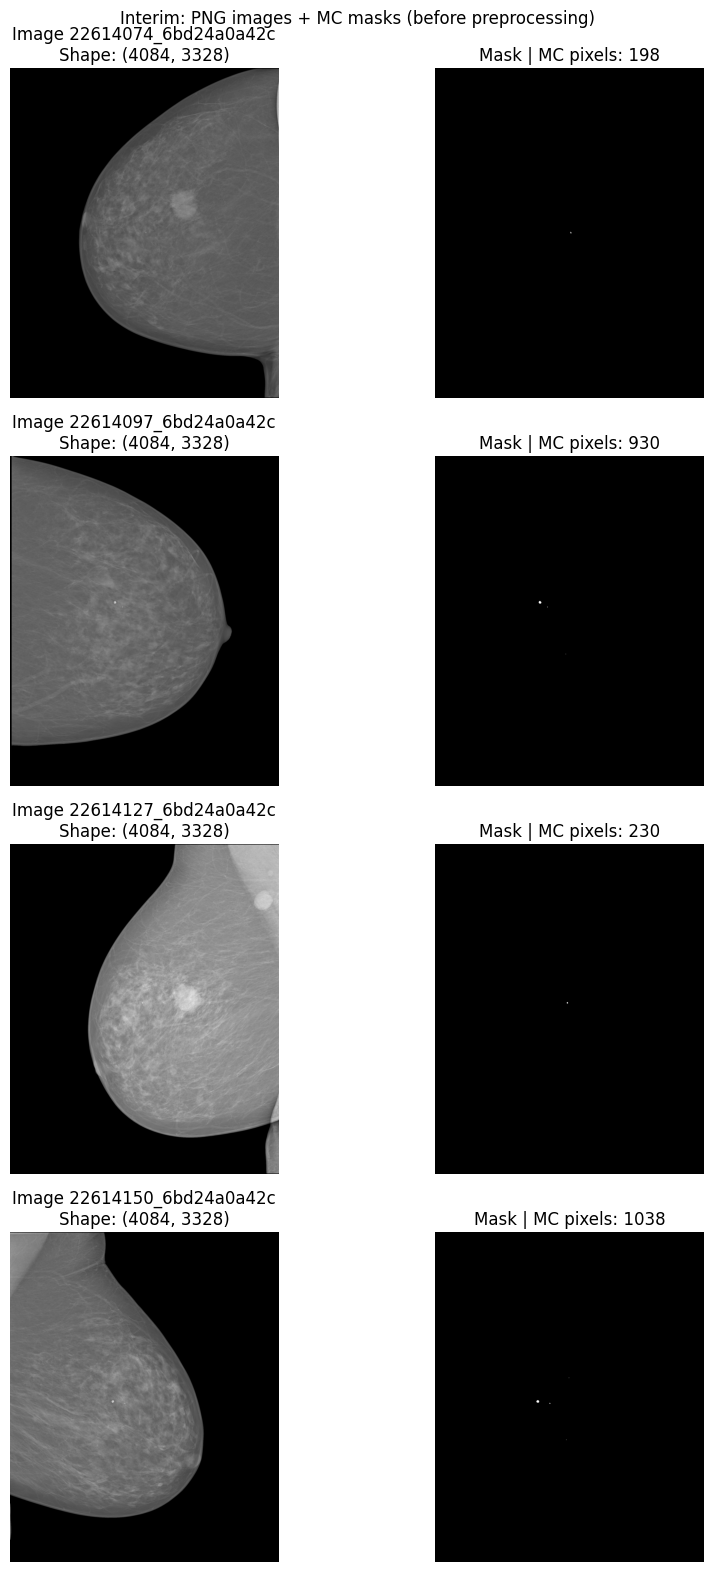

In [4]:
df = pd.read_csv(str(CSV_PATH))
print(f'MC cases in CSV: {len(df)}')
print(f'Split distribution:\n{df.split.value_counts()}')
print(f'\nBI-RADS distribution:\n{df.birads.value_counts().sort_index()}')

# Show 4 image+mask pairs from interim
mc_cases = [r for _, r in df.iterrows()
            if (INT_MASK / r.png_name).exists() and
               cv2.imread(str(INT_MASK / r.png_name), cv2.IMREAD_GRAYSCALE).max() > 0]
mc_cases = mc_cases[:4]

fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle('Interim: PNG images + MC masks (before preprocessing)', fontsize=12)
for row, r in enumerate(mc_cases):
    img  = cv2.imread(str(INT_PNG  / r.png_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(INT_MASK / r.png_name), cv2.IMREAD_GRAYSCALE)
    mc_px = np.sum(mask > 0)
    axes[row,0].imshow(img,  cmap='gray')
    axes[row,0].set_title(f'Image {r.png_name[:20]}\nShape: {img.shape}')
    axes[row,0].axis('off')
    axes[row,1].imshow(mask, cmap='gray')
    axes[row,1].set_title(f'Mask | MC pixels: {mc_px}')
    axes[row,1].axis('off')
plt.tight_layout()
plt.show()

## 4. Processed Images (after flip + artifact removal + CLAHE)

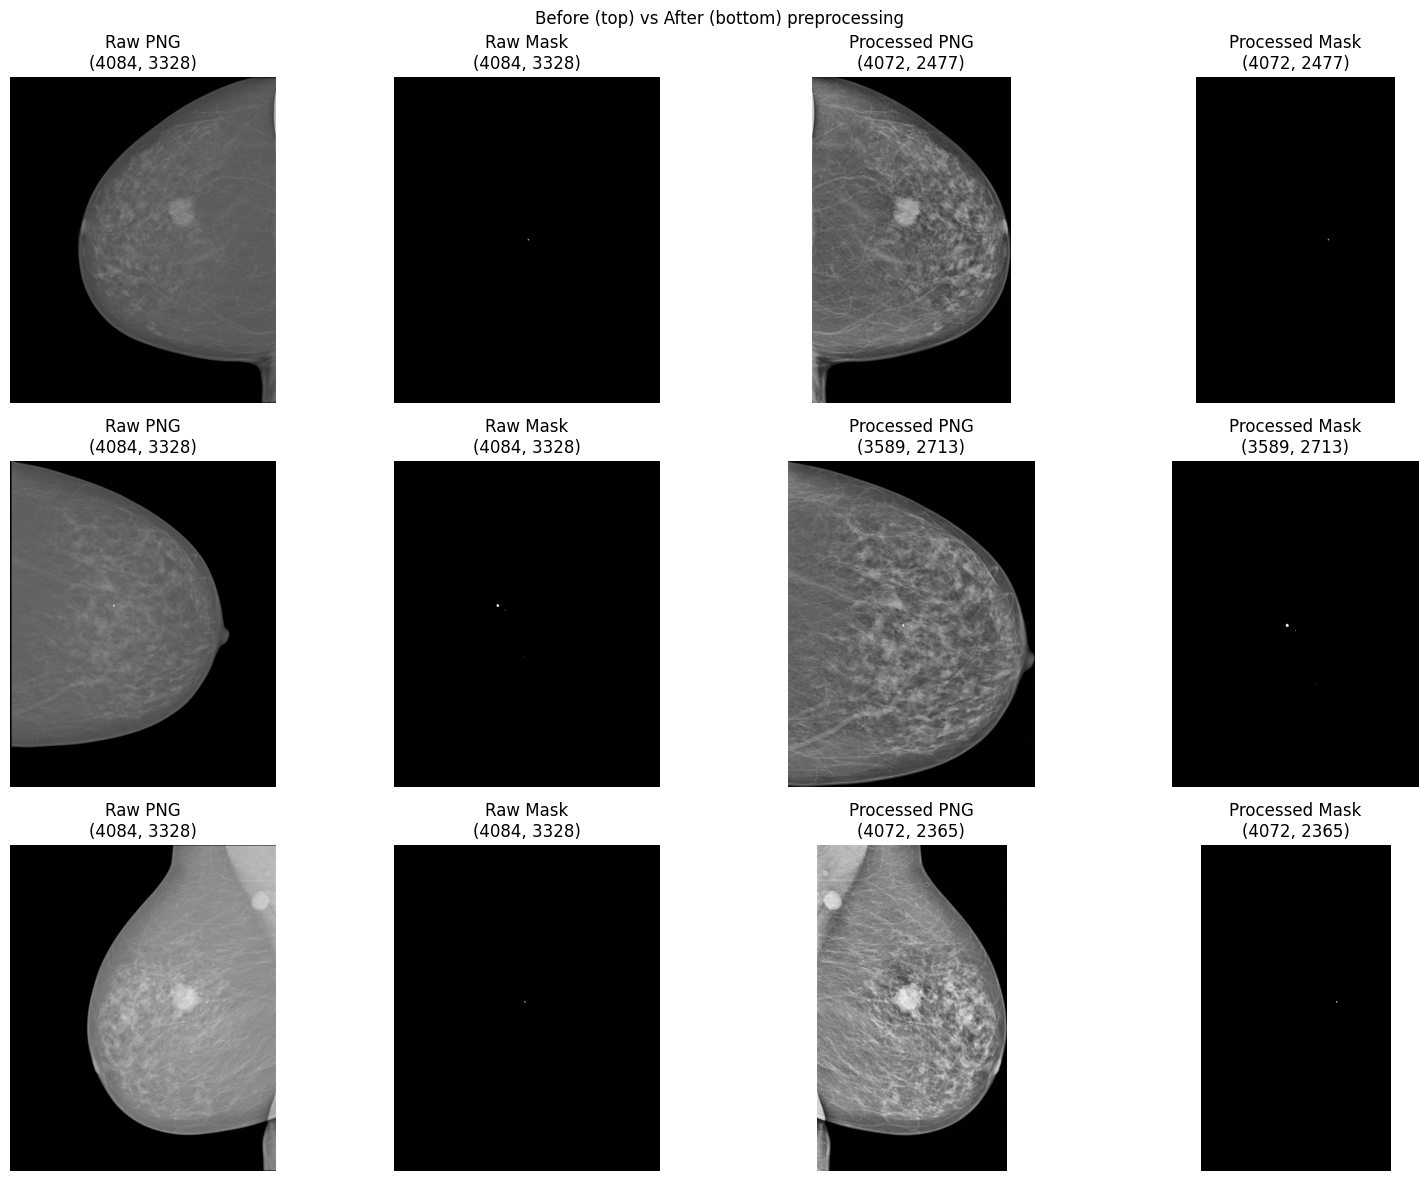

Raw image sizes   — H: 3698±378  W: 2935±384
Processed sizes   — H: 3102±511  W: 1514±364
Average reduction : 56.7%


In [5]:
# Compare before vs after preprocessing
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Before (top) vs After (bottom) preprocessing', fontsize=12)
titles = ['Raw PNG', 'Raw Mask', 'Processed PNG', 'Processed Mask']
for i, t in enumerate(titles):
    axes[0, i].set_title(t, fontsize=10)

cases = mc_cases[:3]
for row, r in enumerate(cases):
    img_raw  = cv2.imread(str(INT_PNG   / r.png_name), cv2.IMREAD_GRAYSCALE)
    mask_raw = cv2.imread(str(INT_MASK  / r.png_name), cv2.IMREAD_GRAYSCALE)
    img_proc = cv2.imread(str(PROC_PNG  / r.png_name), cv2.IMREAD_GRAYSCALE)
    mask_proc= cv2.imread(str(PROC_MASK / r.png_name), cv2.IMREAD_GRAYSCALE)
    for col, (im, title) in enumerate(zip(
            [img_raw, mask_raw, img_proc, mask_proc], titles)):
        if im is not None:
            axes[row, col].imshow(im, cmap='gray')
            axes[row, col].set_title(f'{title}\n{im.shape}')
        axes[row, col].axis('off')
plt.tight_layout()
plt.show()

# Image size analysis
sizes_raw  = [cv2.imread(str(INT_PNG/r.png_name), cv2.IMREAD_GRAYSCALE).shape
              for _, r in df.iterrows() if (INT_PNG/r.png_name).exists()]
sizes_proc = [cv2.imread(str(PROC_PNG/r.png_name), cv2.IMREAD_GRAYSCALE).shape
              for _, r in df.iterrows() if (PROC_PNG/r.png_name).exists()]
print(f'Raw image sizes   — H: {np.mean([s[0] for s in sizes_raw]):.0f}±{np.std([s[0] for s in sizes_raw]):.0f}  W: {np.mean([s[1] for s in sizes_raw]):.0f}±{np.std([s[1] for s in sizes_raw]):.0f}')
print(f'Processed sizes   — H: {np.mean([s[0] for s in sizes_proc]):.0f}±{np.std([s[0] for s in sizes_proc]):.0f}  W: {np.mean([s[1] for s in sizes_proc]):.0f}±{np.std([s[1] for s in sizes_proc]):.0f}')
print(f'Average reduction : {(1 - np.prod(np.mean(sizes_proc,axis=0)) / np.prod(np.mean(sizes_raw,axis=0)))*100:.1f}%')

## 5. Segmentation Patches (256×256, positive only)

CV pool patches  : 2417
Test patches     : 184
Total patches    : 2601

MC pixels per patch (sample of 100):
  Min    : 6
  Median : 30
  Mean   : 71
  Max    : 449


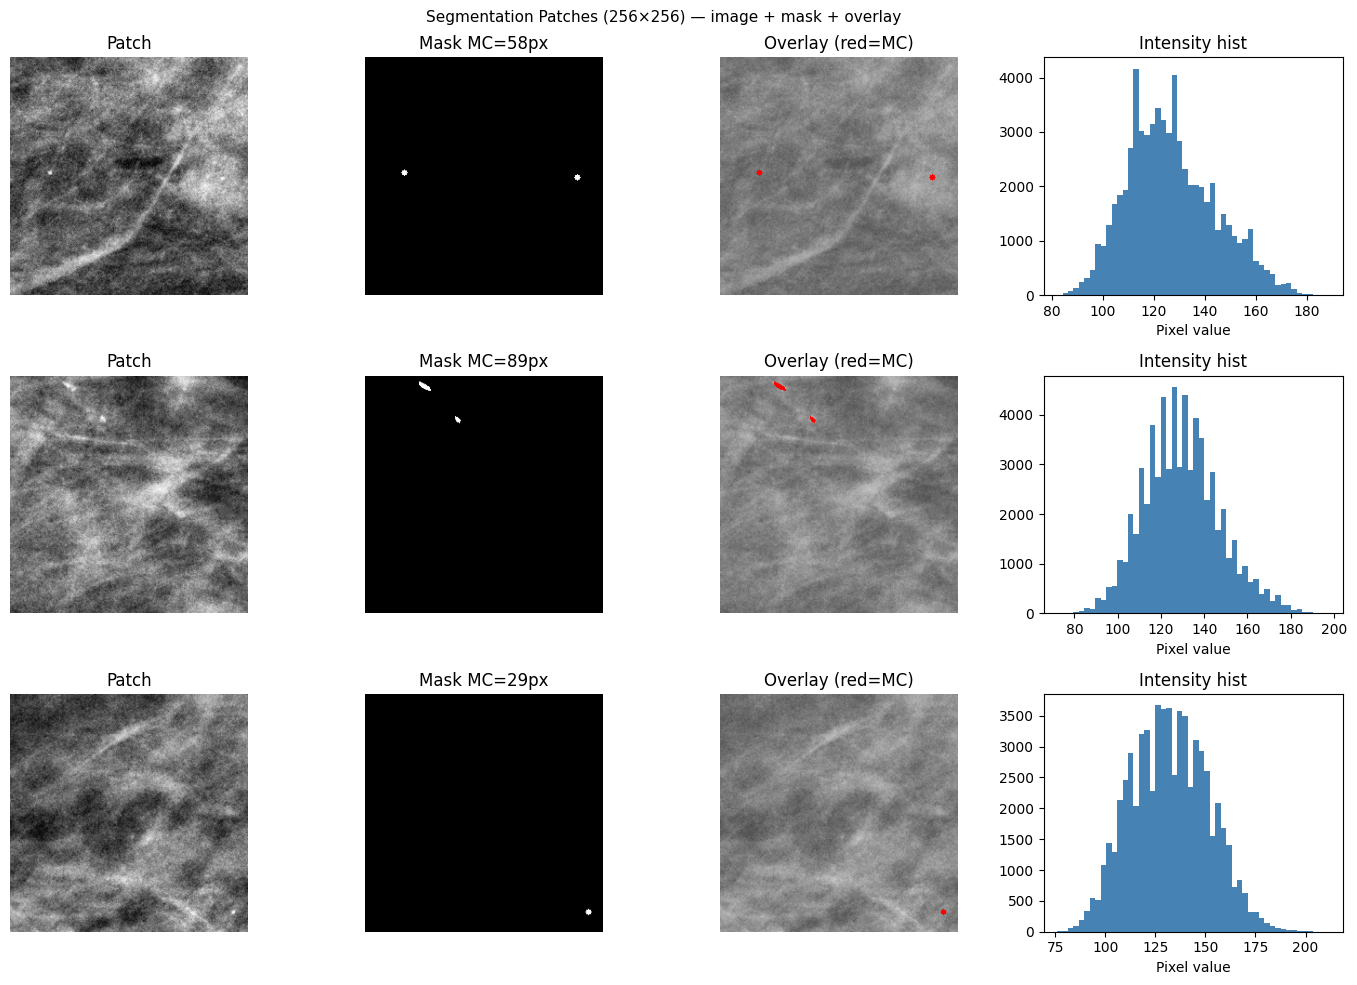

In [6]:
all_imgs  = sorted((PATCH_ALL  / 'images').glob('*.png'))
test_imgs = sorted((PATCH_TEST / 'images').glob('*.png'))
all_masks = sorted((PATCH_ALL  / 'masks').glob('*.png'))

print(f'CV pool patches  : {len(all_imgs)}')
print(f'Test patches     : {len(test_imgs)}')
print(f'Total patches    : {len(all_imgs)+len(test_imgs)}')

# MC pixel statistics
mc_pixels = [np.sum(cv2.imread(str(m), cv2.IMREAD_GRAYSCALE) > 0)
             for m in all_masks[:100]]
print(f'\nMC pixels per patch (sample of 100):')
print(f'  Min    : {min(mc_pixels)}')
print(f'  Median : {np.median(mc_pixels):.0f}')
print(f'  Mean   : {np.mean(mc_pixels):.0f}')
print(f'  Max    : {max(mc_pixels)}')

# Show 6 patch + mask pairs
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Segmentation Patches (256×256) — image + mask + overlay', fontsize=11)
for row in range(3):
    img_p  = cv2.imread(str(all_imgs[row]),  cv2.IMREAD_GRAYSCALE)
    mask_p = cv2.imread(str(all_masks[row]), cv2.IMREAD_GRAYSCALE)
    overlay = cv2.cvtColor(img_p, cv2.COLOR_GRAY2RGB)
    overlay[mask_p > 0] = [255, 0, 0]
    axes[row,0].imshow(img_p,  cmap='gray'); axes[row,0].set_title('Patch'); axes[row,0].axis('off')
    axes[row,1].imshow(mask_p, cmap='gray'); axes[row,1].set_title(f'Mask MC={np.sum(mask_p>0)}px'); axes[row,1].axis('off')
    axes[row,2].imshow(overlay);             axes[row,2].set_title('Overlay (red=MC)'); axes[row,2].axis('off')
    axes[row,3].hist(img_p.flatten(), bins=50, color='steelblue')
    axes[row,3].set_title('Intensity hist'); axes[row,3].set_xlabel('Pixel value')
plt.tight_layout()
plt.show()